**PROJETO DE COLORIZAÇÃO DE IMAGENS PRETO E BRANCO USANDO DEEP LEARNING**

Importando as bibliotecas e frameworks necessários ao desempenho do projeto.

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset
from torchvision.datasets import STL10
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

# importando o dataset (STL10)
dataset = STL10(
    root="data",
    split="train",
    download=True
)

100%|██████████| 2.64G/2.64G [03:29<00:00, 12.6MB/s]


Definindo o dataset que será usado, o STL10, segundo as especificações da interface de PyTorch para os chamados map styled datasets (implementando os métodos init, len e getitem).

In [ ]:
class ImageDataset(Dataset):

  def __init__(self, root, split):

    # importando o dataset a ser usado (o STL10)
    self.dataset = STL10(
      root = root,
      split = split,
      download = True
    )

    # definindo os transformers desse dataset
    self.to_gray = transforms.Grayscale(1)
    self.to_tensor = transforms.ToTensor()

  # método que retorna o tamanho do dataset
  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    # captura somente a imagem (o dado tem formato de tupla, em que a imagem é
    # o primeiro elemento)
    img = self.dataset[idx][0]

    # transformando a imagem do dataset em meramente P&B e, depois, em tensor
    grayImg = self.to_gray(img)
    grayImg = self.to_tensor(grayImg)

    # imagem original transformada em tensor
    colorImg = self.to_tensor(img)

    # retorna ambas imagens P&B e colorida
    return grayImg, colorImg


Definindo o DataLoader que usaremos. Esta ferramenta tem a função de viabilizar a iteração do dataset e o acesso às imagens que ele possui.

In [ ]:
# definindo o dataset a partir do CelebA, partindo do root e utilizando os dados
# com a flag "train" que estão em CelebA
trainDataset = ImageDataset("data/", "train")

# definindo o dataloader atribuindo os seguintes parametros: dataset sendo o
# definido anteriormente, lotes de tamanho 32, shuffle = true para misturar as
# imagens
trainDataloader = DataLoader(
   trainDataset,
   batch_size = 32,
   shuffle = True
)

Definindo a rede neural que será usada, utilizando um Autoencoder convolucional, ou seja, baseado na arquitetura CNN. As redes neurais convolucionais (CNN's) são amplamente usadas para desempenhar tarefas que envolvem o processamento de imagens. O Autoencoder, por sua vez, pode ser decomposto em três partes:

i) o Encoder, que decompõe a entrada, extraindo informações importantes da imagem ainda na escala de cinza, de forma que o modelo possa "compreendê-la";

ii) o Bottleneck, que guarda a versão mais comprimida da entrada, onde a rede neural identificará os padrões e características mais importantes do dado;

iii) o Decoder, que reconstruirá a imagem, prevendo e atribuindo cores a cada pixel (antes limitados à escala de cinza), gerando uma saída.

Encoder e Decoder constituem redes neurais convolucionais complementares, que funcionam de forma encadeada.

Foram usadas 4 camadas convolucionais em cada, além da camada do Bottleneck, totalizando 9 camadas. Por convenção, iniciamos com 32 camadas de saída e um kernel 3x3, além de aplicarmos um padding para preservar as características da imagem.

As camadas são do tipo conv2d. A função de ativação usada entre as camadas foi ReLU (Rectified Linear Unit). Ao final, para a camada de saída, usamos a função de ativação Sigmoid.

No encoder, vão aumentando o número de canais de saída e, aos poucos, diminui-se a resolução, preservando essencialmente as bordas e as margens. No bottleneck, temos o momento de menor resolução da imagem (ela encontra-se "comprimida") em que se preservam apenas suas características mais relevantes. No decoder, o dado comprimido é reconstruído, aumentando a resolução, agora atribuindo cores.


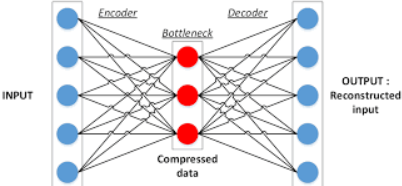

In [ ]:
class AutoEncoder(nn.Module):
  def __init__(self):

    # tendo em vista que essa é uma arquitetura feedforward (ou seja, os dados
    # são passados por camadas de forma linear em uma direção), usamos o método
    # Sequential, que como o próprio nome sugere, faz a transmissão do dado da
    # entrada camada a camada na ordem definida e submetendo-os a cada uma
    # de suas respectivas funções de ativação.

    super().__init__()

    # usamos stride > 1 para diminuir a resolução, fazendo um downsampling
    self.encoder = nn.Sequential(
        nn.Conv2d(1, 32, 3, padding=1),
        nn.ReLU(),
        nn.Conv2d(32, 64, 3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(64, 128, 3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(128, 256, 3, stride=2, padding=1),
        nn.ReLU()
    )

    # "gargalo", em que se tem o maior número de canais para aument
    self.bottleneck = nn.Sequential(
        nn.Conv2d(256, 512, 3, padding=1),
        nn.ReLU()
    )

    # estabelecemos o processo inverso para o decodificador. para isso, fazemos
    # upsampling para garantir o aumento da resolução
    self.decoder = nn.Sequential(
        nn.Upsample(scale_factor=2),
        nn.Conv2d(512, 256, 3, padding=1),
        nn.ReLU(),
        nn.Upsample(scale_factor=2),
        nn.Conv2d(256, 128, 3, padding=1),
        nn.ReLU(),
        nn.Upsample(scale_factor=2),
        nn.Conv2d(128, 64, 3, padding=1),
        nn.ReLU(),
        nn.Conv2d(64, 3, 3, padding=1),
        nn.Sigmoid()
    )

  # define a computação da entrada que deverá ser feita pela rede neural para
  # gerar uma saída
  def forward(self, data):
    data = self.encoder(data)
    data = self.bottleneck(data)
    data = self.decoder(data)
    return data


Nesta etapa, treinaremos o modelo.

Por convenção, dado que temos um problema de regressão, utilizamos o Otimizador Adam e MSE (Mean Squared Error) / L2 como função de perda para estimar a diferença entre a performance de nosso modelo e as fotos reais.
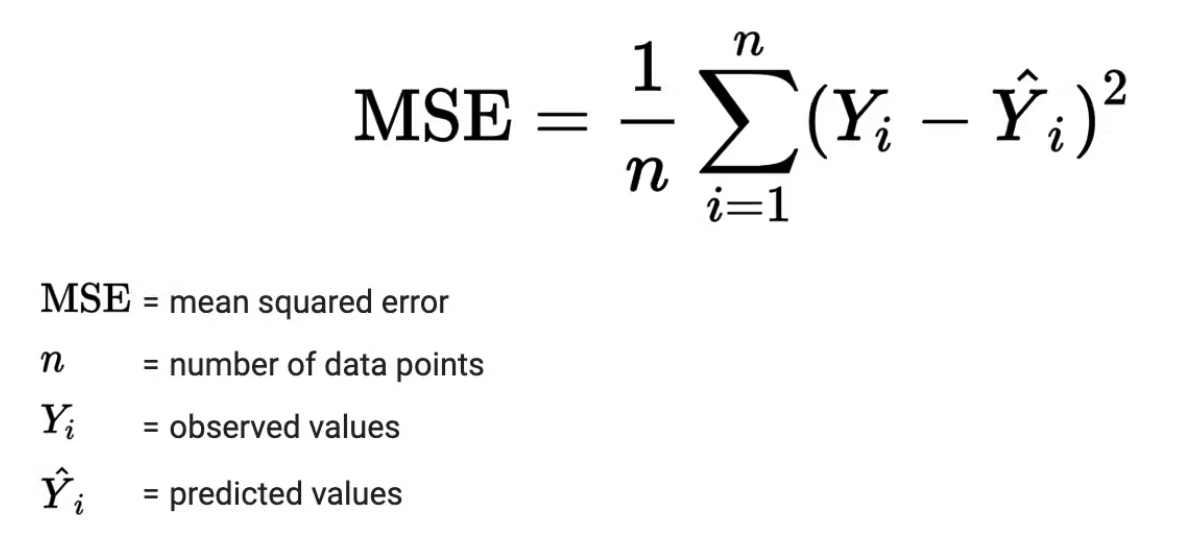




In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device being used: {device}")
model = AutoEncoder().to(device)

# definindo as funções de perda e o otimizador
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# número de épocas definido = 50. uma época configura uma iteração completa em
# todo o dataset.
epoch_num = 50
for epoch in range(1, epoch_num + 1) :
  # acumula a perda total por época
  currenttotalloss = 0
  for grayImg, colorImg in trainDataloader:

        # captura uma imagem em P&B e colorida
        grayImg = grayImg.to(device)
        colorImg = colorImg.to(device)

        # submete a imagem P&B ao modelo. coloca sua saída na loss function e
        # compara à imagem original para calcular a "perda"
        modeloutput = model(grayImg)
        loss = criterion(modeloutput, colorImg)

        # limpa os gradientes anteriores
        optimizer.zero_grad()
        # calcula os gradientes usando backpropagation
        loss.backward()
        # atualiza os parâmetros do modelo com base nos gradientes atuais
        optimizer.step()

        # soma a loss desse batch ao acumulado da epoch
        currenttotalloss += loss.item()

  # calcula a média da época
  averageloss = currenttotalloss / len(trainDataloader)

  # imprimindo a perda que houve em cada época
  print(f'Epoch nº{epoch} -> Loss = {averageloss:.4f}')

Device being used: cuda
Epoch nº1 -> Loss = 0.0222
Epoch nº2 -> Loss = 0.0131
Epoch nº3 -> Loss = 0.0117
Epoch nº4 -> Loss = 0.0106
Epoch nº5 -> Loss = 0.0099
Epoch nº6 -> Loss = 0.0094
Epoch nº7 -> Loss = 0.0090
Epoch nº8 -> Loss = 0.0087
Epoch nº9 -> Loss = 0.0085
Epoch nº10 -> Loss = 0.0083
Epoch nº11 -> Loss = 0.0080
Epoch nº12 -> Loss = 0.0080
Epoch nº13 -> Loss = 0.0079
Epoch nº14 -> Loss = 0.0079
Epoch nº15 -> Loss = 0.0076
Epoch nº16 -> Loss = 0.0074
Epoch nº17 -> Loss = 0.0074
Epoch nº18 -> Loss = 0.0072
Epoch nº19 -> Loss = 0.0072
Epoch nº20 -> Loss = 0.0071
Epoch nº21 -> Loss = 0.0070
Epoch nº22 -> Loss = 0.0069
Epoch nº23 -> Loss = 0.0069
Epoch nº24 -> Loss = 0.0067
Epoch nº25 -> Loss = 0.0067
Epoch nº26 -> Loss = 0.0067
Epoch nº27 -> Loss = 0.0066
Epoch nº28 -> Loss = 0.0066
Epoch nº29 -> Loss = 0.0065
Epoch nº30 -> Loss = 0.0064
Epoch nº31 -> Loss = 0.0064
Epoch nº32 -> Loss = 0.0062
Epoch nº33 -> Loss = 0.0062
Epoch nº34 -> Loss = 0.0061
Epoch nº35 -> Loss = 0.0061
Epoch

Agora, definimos uma interface para melhor visualizar os resultados da colorização de imagens realizada pelo nosso modelo.

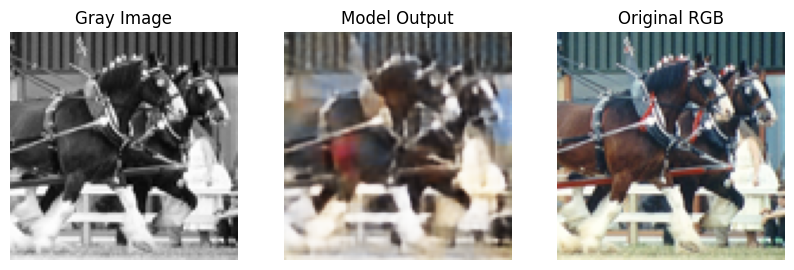

In [ ]:
model.eval()
grayImg, colorImg = next(iter(trainDataloader))
grayImg = grayImg.to(device)

with torch.no_grad():
    pred = model(grayImg)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Gray Image")
plt.imshow(grayImg[0].cpu().squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Model Output")
plt.imshow(pred[0].cpu().permute(1,2,0))
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Original RGB")
plt.imshow(colorImg[0].permute(1,2,0))
plt.axis("off")

plt.show()


**Fontes:**

https://docs.pytorch.org/docs/stable/index.html

https://www.deeplearningbook.com.br/as-principais-arquiteturas-de-redes-neurais/

https://www.alura.com.br/artigos/arquiteturas-de-redes-neurais?srsltid=AfmBOoqu7SEEwqEHouEMY_gr7qn8FZ5ayH6xCyqRR3xs9FITKGQjiDEv#autoencoders

https://www.ibm.com/think/topics/encoder-decoder-model

https://www.gabormelli.com/RKB/Convolutional_(CNN/CNN)-based_Encoder-Decoder_Neural_Network

https://www.geeksforgeeks.org/machine-learning/introduction-to-upsampling-and-downsampling-imbalanced-data-in-python/

https://medium.com/analytics-vidhya/downsampling-and-upsampling-of-images-demystifying-the-theory-4ca7e21db24a

https://www.emergentmind.com/topics/encoder-decoder-convolutional-neural-network

https://www.geeksforgeeks.org/deep-learning/pytorch-dataloader/

https://www.geeksforgeeks.org/machine-learning/implement-convolutional-autoencoder-in-pytorch-with-cuda/

https://www.geeksforgeeks.org/deep-learning/how-to-calculate-optimal-batch-size-for-training-neural-networks/

https://neptune.ai/blog/pytorch-loss-functions

https://discuss.pytorch.org/t/what-step-backward-and-zero-grad-do/33301

https://medium.com/@saiwadotai/epoch-in-machine-learning-understanding-the-core-of-model-training-bfd64bbd5604

https://medium.com/@sahin.samia/train-a-neural-network-in-pytorch-a-complete-beginners-walkthrough-3897d18d6078